In [ ]:
"""
# For feature example (code contribution):
[x] Show recording of transmembrane currents individually; there is some baseline code
    for this that I need to migrate to this repository
[-] Likely remove the dipole reconstruction from_components for this PR; it's not
  strictly necessary and not complete
[x] Dipole reconstruction from i_mem (total transmembrane current) can be kept in the
    example notebook for this PR, as it is complete and shows off new use cases. The
    function herein should be adapted to remove the from_components section, which is
    still a work in progress

# For dipole reconstruction (science contribution):
[x] add isec to soma calculation function, which should be allowed since soma has only
    one segment, and isec should be the transmembrane synaptic current component that
    is missing
[x] run function with isec, see if dipole reproduction matches
[ ] potentially try reconstruction for one cell only to interrogate discrepancies
[ ] don't need vars exposed here:
      - net.cell_types["L5_pyramidal"]["cell_object"].to_dict()

# Notes on outcome of dipole reconstruction
- The normalized RMSE (NRMSE) in the example above is 1.21%
- Over 98.7% of the variance in the i_mem dipole is accounted for by our reconstruction
  from summing over the individual current components
- The remaining 1.21% of unexplained variance is likely due to noise from small timing
  offsets in how NEURON updates versus records variables, or from floating-point
  (rounding) differences that compound when summing over many arrays
  - Re: NEURON timing offsets: Some currents (e.g., ina) are updated at the beginning
    of a timestep, while others (e.g., agg_i_cap) depend on the voltage change across
    the timestep. agg_i_mem captures the exact timing used by the solver, whereas
    the sum in our reconstructed dipole might be slightly "out of phase" at times due
    to how the currents are updated
"""

: 

In [ ]:
#import bpy
import matplotlib.pyplot as plt
import numpy as np
from IPython.core.getipython import get_ipython
from matplotlib.lines import Line2D

from hnn_core import (
    JoblibBackend,
    jones_2009_model,
    simulate_dipole,
)
from hnn_core.cells_default import pyramidal
from hnn_core.network_builder import load_custom_mechanisms
from hnn_core.network_models import add_erp_drives_to_jones_model

: 

In [ ]:
net = jones_2009_model()
add_erp_drives_to_jones_model(net)

n_trials = 1

if "dpls" not in locals():
    with JoblibBackend(8):
        dpls = simulate_dipole(
            net,
            tstop=170.0,
            n_trials=n_trials,
            record_agg_i_mem="all",
            # record_agg_ina="all",
            # record_agg_ik="all",
            record_agg_i_cap="all",
            record_ina_hh2="all",
            record_ik_hh2="all",
            record_ik_kca="all",
            record_ik_km="all",
            record_ica_ca="all",
            record_ica_cat="all",
            record_il_hh2="all",
            record_i_ar="all",
            record_isec="all",
        )

scaling_factor = 3000
for dpl in dpls:
    dpl.scale(scaling_factor)

dpl = dpls[0]
dpl_plot = dpl.plot(
    layer=["L5"],
)

: 

In [27]:
def postproc_tm_currents(
    net,
    trial=0,
    cell_type="L5_pyramidal",
    scaling_factor=3000,
    from_components=False,
):
    """
    Function for processing transmembrane currents to recreate the dipole moment
    calculated from the axial currents in hnn_core. This can be done from either the
    total recorded transmembrane current, or from the constituent components.

    Note: isec (the transmembrane synaptic current) is part of the total transmembrane
    current, but is *not* aggregated with the other component channel currents
    in this function. This is due to the fact that isec contains *section-specific*
    currents (since synapses are placed at the section midpoint), as opposed to
    *segment-specfic* currents, which are required for this method of recreating
    the dipole.

    Parameters
    ----------
    net : Network object
        The network object containing the simulation data.
    trial : int
        The index of the trial to use
    cell_type : str
        The cell type to process
    scaling_factor : float
        The scaling factor to apply to the dipole
    from_components : bool
        if True, use agg_i_mem to reproduce the dipole. if False, use the component
        currents for either L5_pyramidal or L2_pyramidal

    Returns
    -------
    dipole : np.ndarray
        The reconstructed dipole moment from transmembrane currents.
    """

    load_custom_mechanisms()

    # initialize variable to hold dipole data
    dipole = None

    # build a template cell to get "metadata" for sections
    template_cell = pyramidal(cell_name=cell_type)
    template_cell.build(sec_name_apical="apical_trunk")

    # get the relative endpoints for each section from the template cell
    rel_endpoints = {}
    for sec_name, sec in template_cell._nrn_sections.items():
        start = np.array([sec.x3d(0), sec.y3d(0), sec.z3d(0)])
        # sec.n3d() returns the number of 3D points along a section; essentially len()
        # so "sec.n3d() - 1" is the index of the last 3D point
        end = np.array(
            [sec.x3d(sec.n3d() - 1), sec.y3d(sec.n3d() - 1), sec.z3d(sec.n3d() - 1)]
        )
        rel_endpoints[sec_name] = (start, end)

    if not from_components:
        all_tm_channels = ["agg_i_mem"]
    else:
        if cell_type == "L5_pyramidal":
            all_tm_channels = [
                "agg_i_cap",
                "ina_hh2",
                "ik_hh2",
                "ik_kca",
                "ik_km",
                "ica_ca",
                "ica_cat",
                "il_hh2",
                "i_ar",
            ]
        elif cell_type == "L2_pyramidal":
            all_tm_channels = [
                "agg_i_cap",
                "ina_hh2",
                "ik_hh2",
                "ik_km",
                "il_hh2",
            ]
        else:
            raise ValueError(
                f"Valid channels types for {cell_type} are not known.\n"
                "Please pass the channels types as a list of str to tm_channels"
            )

    # loop through GIDs for the cell_type of interest
    for gid in net.gid_ranges[cell_type]:
        # get the updated soma position for this instantiation of the cell
        # index of the first cell: e.g., 170 for the first L5Pyr cell
        start_index = net.gid_ranges[cell_type][0]
        # get soma position from position dictionary, which uses its own indexing
        # that does not match the GID, hence the "- start_index"
        soma_pos = np.array(net.pos_dict[cell_type][gid - start_index])

        # create a dictionary of all channel data for the cell
        cell_channels = {
            ch: net.cell_response.transmembrane_currents[ch][trial][gid]
            for ch in all_tm_channels
        }

        # get the cell sections to loop over
        # the key used shouldn't matter, but we don't want to hard code it since
        # we can pass different channels to this function, so we get it dynamically
        first_key = list(cell_channels.keys())[0]
        cell_sections = list(cell_channels[first_key].keys())

        for sec_name in cell_sections:
            # offset the start/end positions by the realized soma position for this
            # cell instantiation
            start_rel, end_rel = rel_endpoints[sec_name]
            start = start_rel + soma_pos
            end = end_rel + soma_pos

            # get the normalized segment positions along the cell section
            nseg = len(cell_channels[first_key][sec_name])
            seg_positions = [(i - 0.5) / nseg for i in range(1, nseg + 1)]

            for pos, seg_key in zip(
                seg_positions,
                cell_channels[first_key][sec_name].keys(),
            ):
                # convert the normalized position to the absolute position
                # via linear interpolation
                abs_pos = start + pos * (end - start)
                # simplification: we are using the z position only here we only
                # need the vertical component of the dipole momen
                # we do *not* need to do geometric projection (via cos_theta)
                # as we do for the dipole calculation from axial currents
                z_i = abs_pos[2]

                # sum all currents for this segment
                I_t = np.zeros_like(
                    np.array(cell_channels[first_key][sec_name][seg_key])
                )
                for ch in all_tm_channels:
                    # get channel data
                    vec = np.array(cell_channels[ch][sec_name][seg_key])

                    # get segment area and convert from µm^2 to cm^2
                    seg = template_cell._nrn_sections[sec_name](pos)
                    area_um2 = seg.area()  # µm^2
                    area_cm2 = area_um2 * 1e-8  # cm^2

                    if ch == "agg_i_mem":
                        # agg_i_mem is not recorded continuously as a density; it is
                        # recorded after each timestep. Ergo, the units conversion
                        # here is not necessary as the units are already in nA
                        #
                        # multiplying the contribution by zi in um will give us fAm,
                        # so we will later need to divide by 1e6 to convert to nAm
                        I_abs = vec
                    # convert densities (mA/cm^2) to absolute currents (mA)]
                    else:
                        I_abs = vec * area_cm2  # keep as mA

                        # [WIP]
                        # Should I flip sign for the capacitive currents? I *think*
                        # so, but I haven't found direct confirmation of this ...
                        #
                        # I ideally would want to test the sign flip empirically,
                        # and confirm that we can reproduce i_mem by summing up all
                        # of its constituent components. However, we can't get the
                        # per-segment synaptic currents since we model them as point
                        # processes at the midpoint of the section (not the segment);
                        #
                        # Ergo, we are missing the synaptic piece of the total
                        # transmembrane current needed to reproduce i_mem exactly
                        #
                        # Note: isec is the *per-synapse* current, and not the
                        # *per-segment* current that we need
                        if ch == "agg_i_cap":
                            I_abs = I_abs * -1  # flip sign (?)
                        # [end WIP]

                    I_t += I_abs

                # multiple by r_i per Naess 2015 Ch 2 (simplified to zi in this case)
                # for ionic currents, we have 1 mA*um = 1 nAm (correct units)
                # for i_mem, we have nA rather than mA. and 1 nA*um = 1 fAm
                contrib = I_t * z_i

                # for agg_i_mem, divide by 1e6 to convert fAm to nAm
                if not from_components:
                    contrib = contrib / 1e6 * scaling_factor
                else:
                    contrib = contrib * scaling_factor

                if dipole is None:
                    dipole = contrib.copy()
                else:
                    dipole += contrib

    return dipole

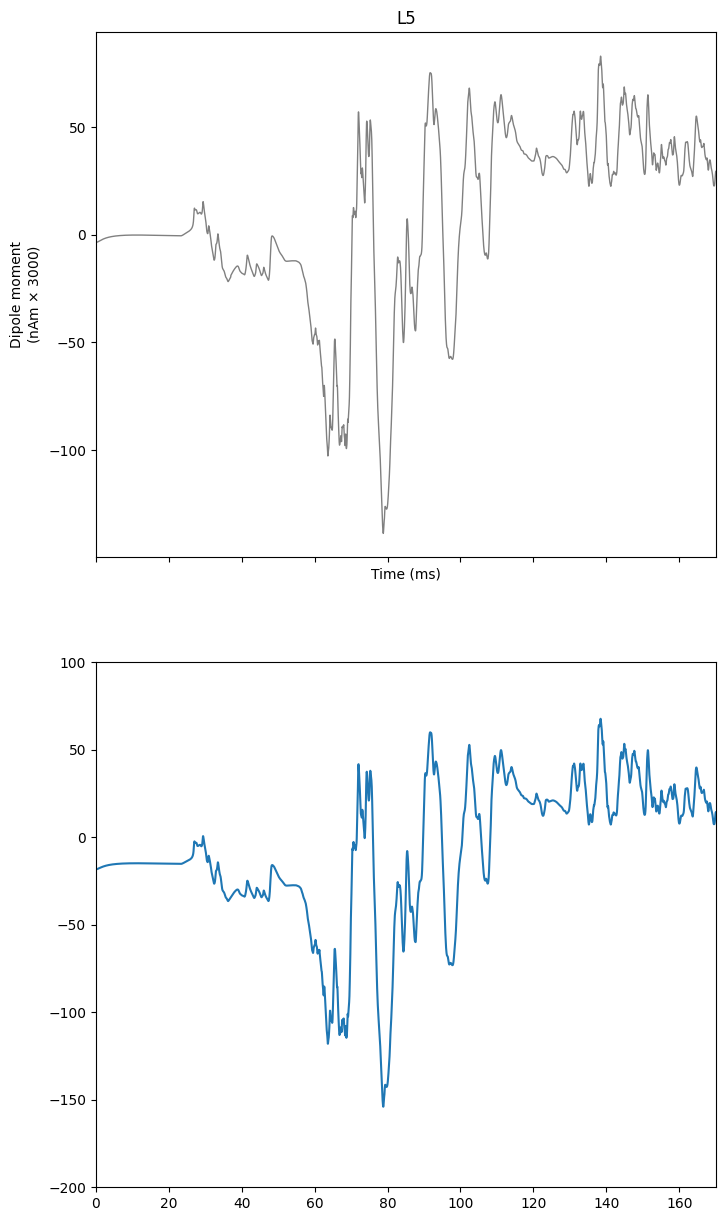

In [31]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(8, 15),
)

test_imem_L5 = postproc_tm_currents(
    net=net,
    from_components=False,
)

ax[1].plot(
    dpl.times,
    test_imem_L5,
)

ax[1].set_ylim(-200, 100)

_ = dpl.plot(
    layer=["L5"],
    ax=ax[0],
)

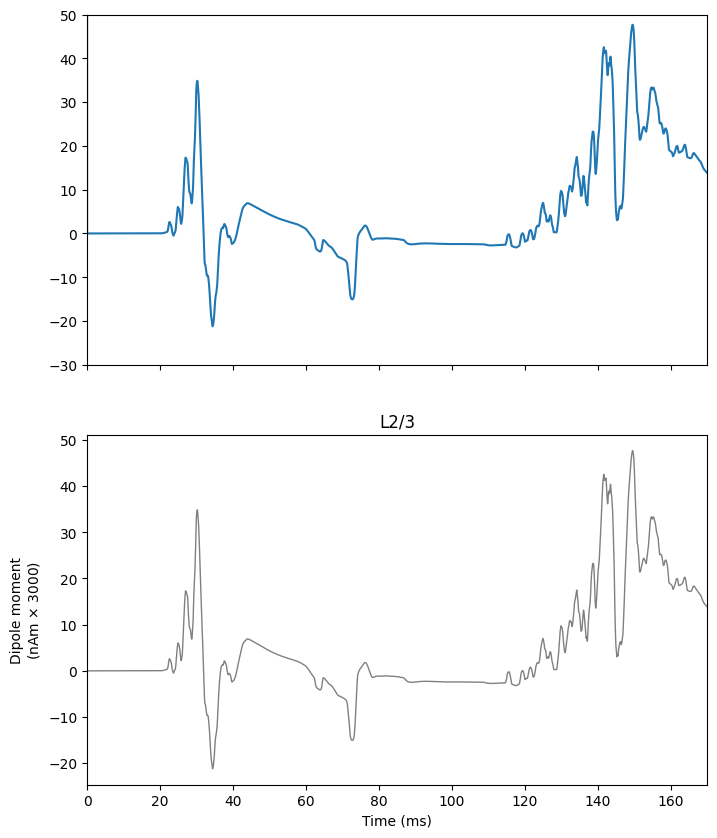

In [33]:
test_imem_L2 = postproc_tm_currents(
    net=net,
    cell_type="L2_pyramidal",
    from_components=False,
)

fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(8, 10),
)

ax[0].plot(
    dpl.times,
    test_imem_L2,
)

ax[0].set_ylim(-30, 50)

_ = dpl.plot(
    layer=["L2"],
    ax=ax[1],
)

In [34]:
# from this we know that ina_hh2 was recorded, but not with actual segment time series.
# the simulator might not be configured to save segment-level values for ina_hh2
# Tryingto do that for i_mem.

print(net.cell_response.transmembrane_currents.keys())
print(type(net.cell_response.transmembrane_currents["ina_hh2"]))
print(len(net.cell_response.transmembrane_currents["ina_hh2"]))
print(net.cell_response.transmembrane_currents["ina_hh2"][0])

#print(net.cell_response.transmembrane_currents["agg_i_mem"][0].keys())
#print(net.cell_response.transmembrane_currents["i_mem"][0][35])

#channel_cell_recordings = net.cell_response.transmembrane_currents["ina_hh2"][0]
#print("Recorded gids:", list(channel_cell_recordings.keys())[:10])
#print("L2 gids:", list(net.gid_ranges["L2_pyramidal"])[:10])
#print("L5 gids:", list(net.gid_ranges["L5_pyramidal"])[:10])

dict_keys(['agg_i_mem', 'agg_ina', 'agg_ik', 'agg_i_cap', 'ina_hh2', 'ik_hh2', 'ik_kca', 'ik_km', 'ica_ca', 'ica_cat', 'il_hh2', 'i_ar'])
<class 'list'>
1
{0: {'soma': {}}, 1: {'soma': {}}, 2: {'soma': {}}, 3: {'soma': {}}, 4: {'soma': {}}, 5: {'soma': {}}, 6: {'soma': {}}, 7: {'soma': {}}, 8: {'soma': {}}, 9: {'soma': {}}, 10: {'soma': {}}, 11: {'soma': {}}, 12: {'soma': {}}, 13: {'soma': {}}, 14: {'soma': {}}, 15: {'soma': {}}, 16: {'soma': {}}, 17: {'soma': {}}, 18: {'soma': {}}, 19: {'soma': {}}, 20: {'soma': {}}, 21: {'soma': {}}, 22: {'soma': {}}, 23: {'soma': {}}, 24: {'soma': {}}, 25: {'soma': {}}, 26: {'soma': {}}, 27: {'soma': {}}, 28: {'soma': {}}, 29: {'soma': {}}, 30: {'soma': {}}, 31: {'soma': {}}, 32: {'soma': {}}, 33: {'soma': {}}, 34: {'soma': {}}, 35: {'apical_trunk': {}, 'apical_1': {}, 'apical_tuft': {}, 'apical_oblique': {}, 'basal_1': {}, 'basal_2': {}, 'basal_3': {}, 'soma': {}}, 36: {'apical_trunk': {}, 'apical_1': {}, 'apical_tuft': {}, 'apical_oblique': {}, 'b

In [ ]:
print(type(test_imem_L5))
print(np.shape(test_imem_L5))
print(np.shape(dpl.times))

In [ ]:
print(net.cell_response.transmembrane_currents.keys())

for key in ["agg_i_mem", "agg_ina", "agg_ik", "agg_i_cap"]:
    print("\nKEY:", key)
    print("type:", type(net.cell_response.transmembrane_currents[key]))
    print("len:", len(net.cell_response.transmembrane_currents[key]))
    print("trial 0 type:", type(net.cell_response.transmembrane_currents[key][0]))
    print("trial 0 preview:", net.cell_response.transmembrane_currents[key][0])

: 

: 

In [20]:
channel = "i_mem"
trial = 0

data = net.cell_response.transmembrane_currents[channel][trial]

for gid in list(data.keys())[:10]:
    print(f"\nGID {gid}")
    for sec, sec_data in data[gid].items():
        print(f"  {sec}: {list(sec_data.keys())}")

KeyError: 'i_mem'

In [22]:
def agg_transmembrane_segment_recordings_by_celltype(
    net,
    trial_number=0,
    cell_type=[
        "L2_pyramidal",
        "L5_pyramidal",
    ],
    target_channel="i_mem",
):
    # get recordings for the target channel and trial number
    channel_cell_recordings = (
        net.cell_response.transmembrane_currents[target_channel][trial_number]  # noqa: E203,W503
    )

    agg_output = {}
    agg_output[target_channel] = {}

    for type in cell_type:
        # limit scope to gids for the specified cell_type
        gids = list(net.gid_ranges[type])
        channel_celltype_recordings = {
            gid: channel_cell_recordings[gid] for gid in gids
        }

        aggregate = {}

        for gid_data_dict in channel_celltype_recordings.values():
            for section_key, section_data_dict in gid_data_dict.items():
                for segment_key, segment_data in section_data_dict.items():
                    values = np.array(segment_data)
                    if section_key not in aggregate:
                        aggregate[section_key] = {}
                    if segment_key not in aggregate[section_key]:
                        aggregate[section_key][segment_key] = np.zeros_like(values)
                    aggregate[section_key][segment_key] += values

        agg_output[target_channel][type] = aggregate

    return agg_output

ina_hh2_segment_data = agg_transmembrane_segment_recordings_by_celltype(
    net,
    trial_number=0,
    #target_channel="ina_hh2",
    target_channel="i_mem",
)

print(ina_hh2_segment_data)

KeyError: 'i_mem'

In [34]:
def agg_transmembrane_section_recordings_by_celltype(
    net,
    trial_number=0,
    cell_type=[
        "L2_pyramidal",
        "L5_pyramidal",
    ],
    target_channel="i_mem",
):
    # get recordings for the target channel and trial number
    channel_cell_recordings = (
        net.cell_response.transmembrane_currents[target_channel][trial_number]  # noqa: E203,W503
    )

    agg_output = {}
    agg_output[target_channel] = {}

    for type in cell_type:
        # limit scope to gids for the specified cell_type
        gids = list(net.gid_ranges[type])
        channel_celltype_recordings = {
            gid: channel_cell_recordings[gid] for gid in gids
        }

        aggregate = {}

        for gid_data_dict in channel_celltype_recordings.values():
            for section_key, section_data_dict in gid_data_dict.items():
                for segment_key, segment_data in section_data_dict.items():
                    values = np.array(segment_data)
                    if section_key not in aggregate:
                        aggregate[section_key] = np.zeros_like(values)
                    aggregate[section_key] += values

        agg_output[target_channel][type] = aggregate

    return agg_output


ina_hh2_section_data = agg_transmembrane_section_recordings_by_celltype(
    net,
    trial_number=0,
    target_channel="ina_hh2",
)

In [35]:
def get_channel_section_data(
    net,
    trial_number=0,
    channels=None,
):
    channel_section_data = {}

    if channels is None:
        channels = list(net.cell_response.transmembrane_currents.keys())

    for channel in channels:
        agg_data_dict = agg_transmembrane_section_recordings_by_celltype(
            net,
            trial_number=trial_number,
            target_channel=channel,
        )
        channel_section_data[channel] = agg_data_dict[channel]

    return channel_section_data


channel_section_data = get_channel_section_data(
    net,
    channels=[
        "ina_hh2",
        "ik_hh2",
        "ik_kca",
        "ik_km",
        "ica_ca",
        "ica_cat",
        "il_hh2",
        "i_ar",
    ],
)

In [36]:
def extract_diameters(
    section_names,
    cell_params,
):
    """
    helper to map section names to their corresponding diameters from
    params_default.py
    """
    extracted = {}
    for name in section_names:
        # adjust the section names to match the default keys
        search_key = name.replace("_", "").lower()

        # look for a key in defaults that contains search_key and "diam"
        found = False

        for cell_param, cell_val in cell_params.items():
            clean_cell_param = cell_param.lower()

            if search_key in clean_cell_param and "diam" in clean_cell_param:
                extracted[name] = cell_val
                found = True
                break

        if not found:
            raise KeyError(
                f"Could not find diameter for section '{name}' in cell_params"
            )

    return extracted


def calculate_neuron_geometry(
    end_pts,
    gap=0,
    x_offsets=None,
):
    """
    calculate the 3D geometry
    """
    # handle horizontal offsets
    x_offs = (
        x_offsets  # noqa: E203,W503
        if x_offsets
        else {
            k: 0
            for k in end_pts.keys()  # noqa: E203,W503
        }
    )
    z_shift = {k: 0 for k in end_pts.keys()}

    # handle vertical offsets ("gap")

    # sort sections by how close they are to soma
    # determine the order in which vertical gaps are processed, since the gaps need
    # to be accumulated as you move away from the soma towards the ends of the
    # dendrites. E.g.:
    # - "soma" is the parent of "apical_trunk", which is the parent of "apical_1" ...
    sorted_sections = sorted(
        # sections
        end_pts.keys(),
        # absolute value of distance from soma on the Z axis
        key=lambda x: abs(end_pts[x][0][2]),
    )

    for child_section in sorted_sections:
        child_section_start = end_pts[child_section][0]

        # set shift for basal_1, which should move in the negative direction along
        # the z axis
        if child_section != "soma" and child_section_start == end_pts["soma"][0]:
            # the vertical offset for basal 2/3 should be negative
            z_shift[child_section] = -gap

        # as we move out from the soma, inherit the gap from the parent section
        for parent_section in end_pts.keys():
            parent_section_end = end_pts[parent_section][1]
            if child_section_start == parent_section_end:
                # for apical_oblique, inherit the parent_section shift, but add 0 gap
                # this keeps it in line with apical_trunk, while allowing apical_1
                # to move higher
                if "oblique" in child_section:
                    z_shift[child_section] = z_shift[parent_section]
                else:
                    current_gap = -gap if "basal" in child_section else gap
                    z_shift[child_section] = z_shift[parent_section] + current_gap
                break

    shifted_coords = {}
    for section, coords in end_pts.items():
        dx = x_offs.get(section, 0)
        dz = z_shift.get(section, 0)
        shifted_coords[section] = {
            "x": [coords[0][0] + dx, coords[1][0] + dx],
            "y": [coords[0][1], coords[1][1]],
            "z": [coords[0][2] + dz, coords[1][2] + dz],
        }

    return shifted_coords


def draw_neuron_on_axis(
    ax,
    shifted_coords,
    diameters,
    colors=None,
    width_scale=1.0,
):
    """
    helper to render the neuron from plot_flat_neuron onto a specific axis
    """
    # use normalized diameter to set line width for sections
    diam_values = list(diameters.values())
    d_min, d_max = min(diam_values), max(diam_values)

    # map section diameters to matplotlib line widths
    # scale based on width_scale parameter
    def diam_to_width(d):
        if d_max > d_min:
            # first, normalize diameters into a fixed range [1, 15]
            # - this range is arbitrary based on what looks reasonable in matplotlib
            base_width = 1 + (d - d_min) / (d_max - d_min) * 14
            # second, apply width_scale multiplier
            scaled = base_width * width_scale
            return scaled
        # fallback line width of 5 times the scales
        return 5 * width_scale

    # plot geometry
    for name, coords in shifted_coords.items():
        width = diam_to_width(
            diameters[name],
        )
        color = colors.get(name, "b") if colors else "b"

        # "butt" capstyle ensures sections to not overlab
        ax.plot(
            coords["x"],
            coords["z"],
            color=color,
            linewidth=width,
            solid_capstyle="butt",
        )


def plot_flat_neuron(
    end_pts,
    defaults,
    x_offsets=None,
    gap=0,
    colors=None,
    figsize=(6, 12),
    width_scale=1.0,
    ax=None,
    show_labels=True,
):
    # get diameters to set widths
    diameters = extract_diameters(
        end_pts.keys(),
        defaults,
    )

    # get full 3D geometry
    full_coords = calculate_neuron_geometry(
        end_pts=end_pts,
        gap=gap,
        x_offsets=x_offsets,
    )

    # get 2D geometry used for plotting from the 3D geometry
    # note that "z" is the vertical component
    coords = {}
    for name, c in full_coords.items():
        coords[name] = {
            "x": c["x"],
            "z": c["z"],
        }

    # if no axis is provided, create a new figure
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    legend_elements = []

    # helper 2: drawing engine
    draw_neuron_on_axis(
        ax=ax,
        shifted_coords=coords,
        diameters=diameters,
        colors=colors,
        width_scale=width_scale,
    )

    # handle labels and legend
    for name, seg_coords in coords.items():
        x = seg_coords["x"]
        # renaming the vertical component "z" to "y" since we're in 2D
        y = seg_coords["z"]
        color = colors.get(name, "b") if colors else "b"

        # use uniform line thickness in the legend
        if colors and name in colors and show_labels:
            legend_elements.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=name,
                ),
            )

        if show_labels:
            ax.text(
                x[1],
                y[1],
                name,
                fontsize=8,
                va="bottom",
                ha="center",
            )

    ax.axis("off")
    if colors and show_labels:
        ax.legend(
            handles=legend_elements,
            loc="upper left",
            fontsize=8,
        )

    # only call if generating a new figure, not if adding to an existing one
    if ax is None:
        plt.show()

# defaults extracted from params_default.py for L5Pyr, but can be grabbed from
# net._params

cell_type = "L5_pyramidal"
default_cell_searchkey = net.cell_types[cell_type]["cell_object"].name
celltype_sections = list(
    net.cell_types["L5_pyramidal"]["cell_object"].sections.keys(),
)

# reduce _params down to current cell_type only
default_cell_keymatches = [
    key for key in list(net._params.keys()) if default_cell_searchkey in key
]

defaults = {
    key: value for key, value in net._params.items() if key in default_cell_keymatches
}


# values pulled directly from _cell_L5Pyr in cells_default
end_pts = {
    "soma": [[0, 0, 0], [0, 0, 23]],
    "apical_trunk": [[0, 0, 23], [0, 0, 83]],
    "apical_oblique": [[0, 0, 83], [-150, 0, 83]],
    "apical_1": [[0, 0, 83], [0, 0, 483]],
    "apical_2": [[0, 0, 483], [0, 0, 883]],
    "apical_tuft": [[0, 0, 883], [0, 0, 1133]],
    "basal_1": [[0, 0, 0], [0, 0, -50]],
    "basal_2": [[0, 0, -50], [-106, 0, -156]],
    "basal_3": [[0, 0, -50], [106, 0, -156]],
}

# endpoints grabbed from procedurally-generated cell
procedural_end_pts = {}
for section in celltype_sections:
    procedural_end_pts[section] = (
        net.cell_types[cell_type]["cell_object"].sections[section].end_pts
    )

x_offsets = {
    "apical_oblique": -5,
    "apical_1": 0,
    "apical_2": 0,
    "apical_tuft": 0,
    "basal_2": -5,
    "basal_3": 5,
}


distinct_colors = {
    "soma": "orange",
    "apical_trunk": "red",
    "apical_oblique": "purple",
    "apical_1": "magenta",
    "apical_2": "pink",
    "apical_tuft": "brown",
    "basal_1": "yellow",
    "basal_2": "olive",
    "basal_3": "darkgreen",
}

blues = {
    "soma": "#4895ef",
    "apical_trunk": "#4cc9f0",
    "apical_oblique": "#caf0f8",
    "apical_1": "#90e0ef",
    "apical_2": "#ade8f4",
    "apical_tuft": "#e0f7fa",
    "basal_1": "#4cc9f0",
    "basal_2": "#90e0ef",
    "basal_3": "#ade8f4",
}

plot_flat_neuron(
    end_pts,
    defaults,
    x_offsets=x_offsets,
    gap=30,
    colors=blues,
    width_scale=2,
)

plot_flat_neuron(
    procedural_end_pts,
    defaults,
    x_offsets=x_offsets,
    gap=0,
    colors=distinct_colors,
    width_scale=2,
)

In [11]:
def draw_neuron_3d(
    ax,
    shifted_coords,
    diameters,
    colors=None,
    width_scale=1.0,
    shade=True,
):
    """
    draw the neuron in 3D using smoothed cylindrical surfaces
    """
    # number of "planes" used to form each cylinder
    # increase for a smoother object
    resolution = 25

    # iterate through segments
    for name, coords in shifted_coords.items():
        # define start and end vectors for the current segment
        start_pt = np.array(
            [
                coords["x"][0],
                coords["y"][0],
                coords["z"][0],
            ]
        )
        end_pt = np.array(
            [
                coords["x"][1],
                coords["y"][1],
                coords["z"][1],
            ]
        )

        # get the segment vector (directional) and its length (magnitude only)
        branch_vec = end_pt - start_pt
        length = np.linalg.norm(branch_vec)

        # failsafe to skip segments with no length
        if length == 0:
            continue

        # get the cylinder radius
        radius = (diameters[name] / 2.0) * width_scale

        # define the cylinder's longitudinal profile (z) and its thickness (r)
        #  - for z_steps, we start at the base, then stay at base for drawing the
        #    "cap", we move to length, then stay at the length for drawing the "cap"
        #  - for r_steps, we start at center, then expand to radius, we stay at radius
        #    while we move to length, then return to the center to create the cap
        z_steps = np.array([0, 0, length, length])
        r_steps = np.array([0, radius, radius, 0])

        # get the angles around the circle for rotation (i.e., 0 to 360 degrees)
        theta = np.linspace(0, 2 * np.pi, resolution)

        # generate coordinates for the cylinder circumference
        theta_grid, z_idx = np.meshgrid(theta, np.arange(len(z_steps)))

        # store the radius for every point on the cylinder surface
        r_grid = r_steps[z_idx]

        # transform r_grid into 3D coordinates
        x_circle = r_grid * np.cos(theta_grid)
        y_circle = r_grid * np.sin(theta_grid)

        # store the height for every point on the cylinder surface
        # does not requite 3D coordinates
        z_grid = z_steps[z_idx]

        # we need to normalize the segment vector by dividing it by its own length
        # this gives us the "pure" direction, which we will use to build our rotation
        # vectors (side_vec and up_vec)
        # if we used the un-normalized vector, the rotation math would scale the
        # cylinder's thickness or stretch the mesh in weird ways
        direction = branch_vec / length

        # rotate and translate the cylinder to match the segment vector
        if np.allclose(direction, [0, 0, 1]) or np.allclose(direction, [0, 0, -1]):
            # handle segments already aligned with the z-axis where no rotation
            # is needed
            x_final = start_pt[0] + x_circle
            y_final = start_pt[1] + y_circle
            z_final = start_pt[2] + (z_grid if direction[2] > 0 else -z_grid)
        else:
            # when rotation is needed, find a "side" vector perpendicular to the branch
            ref_vec = (
                np.array([1, 0, 0]) if abs(direction[0]) < 0.9 else np.array([0, 1, 0])
            )
            side_vec = np.cross(ref_vec, direction)
            side_vec /= np.linalg.norm(side_vec)

            # find an "up" vector perpendicular to both the branch and the side
            up_vec = np.cross(direction, side_vec)

            # transform raw coordinates into the new 3D basis oriented from the
            # start_pt toward the end_pt
            x_final = (
                start_pt[0]
                + direction[0] * z_grid
                + side_vec[0] * x_circle
                + up_vec[0] * y_circle
            )
            y_final = (
                start_pt[1]
                + direction[1] * z_grid
                + side_vec[1] * x_circle
                + up_vec[1] * y_circle
            )
            z_final = (
                start_pt[2]
                + direction[2] * z_grid
                + side_vec[2] * x_circle
                + up_vec[2] * y_circle
            )

        color = colors.get(name, "b") if colors else "b"
        ax.plot_surface(
            x_final,
            y_final,
            z_final,
            color=color,
            linewidth=0,
            antialiased=False,
            shade=shade,
            alpha=1.0,
        )


def plot_3d_neuron(
    end_pts,
    defaults,
    x_offsets=None,
    gap=0,
    colors=None,
    shade=True,
    figsize=(10, 10),
    width_scale=1.0,
    ax=None,
    show_labels=True,
    show_section_labels=False,
):
    diameters = extract_diameters(
        end_pts.keys(),
        defaults,
    )

    coords = calculate_neuron_geometry(
        end_pts=end_pts,
        gap=gap,
        x_offsets=x_offsets,
    )

    if ax is None:
        fig = plt.figure(
            figsize=figsize,
        )
        ax = fig.add_subplot(
            111,
            projection="3d",
        )

    draw_neuron_3d(
        ax=ax,
        shifted_coords=coords,
        diameters=diameters,
        colors=colors,
        width_scale=width_scale,
        shade=shade,
    )

    # handle legend / labels
    legend_elements = []
    for name, seg_coords in coords.items():
        color = (
            colors.get(
                name,
                "b",
            )
            if colors
            else "b"
        )

        # optionally add section labels in the 3D space
        if show_section_labels:
            ax.text(
                seg_coords["x"][1],
                seg_coords["y"][1],
                seg_coords["z"][1],
                name,
                fontsize=8,
            )

        if colors and name in colors:
            legend_elements.append(
                Line2D(
                    [0],
                    [0],
                    color=color,
                    lw=2,
                    label=name,
                ),
            )

    # force equal axis scaling to prevent neurons from looking stretched
    # ------------------------------
    # matplotlib stretches whatever ranges we give it to fill a square area in 3d
    # space. so we need to ensure that the "span" is the same for each axis,
    # otherwise axes may be stretched to fill the cube, distorting the shapes

    # get the ranges
    x_lim = ax.get_xlim3d()
    y_lim = ax.get_ylim3d()
    z_lim = ax.get_zlim3d()

    # get the widest range, divide by two since we'll center around the midpoint
    half_max_range = (
        max(
            np.diff(x_lim),
            np.diff(y_lim),
            np.diff(z_lim),
        )[0]
        / 2.0
    )

    # get the midpoint for each range for centering
    mid_x = np.median(x_lim)
    mid_y = np.median(y_lim)
    mid_z = np.median(z_lim)

    # center around the midpoint using half of the maximum range
    ax.set_xlim3d(mid_x - half_max_range, mid_x + half_max_range)
    ax.set_ylim3d(mid_y - half_max_range, mid_y + half_max_range)
    ax.set_zlim3d(mid_z - half_max_range, mid_z + half_max_range)

    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_zlabel("z (µm)")
    ax.set_box_aspect((1, 1, 1))

    # adjust style of the grid
    ax.xaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.yaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.zaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.1)

    if colors and show_labels:
        unique_handles = []
        seen = set()
        for h in legend_elements:
            if h.get_label() not in seen:
                unique_handles.append(h)
                seen.add(h.get_label())
        ax.legend(
            handles=unique_handles,
            loc="upper left",
            fontsize=8,
        )

    return ax


In [12]:
get_ipython().run_line_magic("matplotlib", "tk")

add_gap = False

if add_gap:
    gap = 20
    x_offsets = {
        "apical_oblique": -20,
        "apical_1": 0,
        "apical_2": 0,
        "apical_tuft": 0,
        "basal_2": -20,
        "basal_3": 20,
    }
else:
    gap = 0
    x_offsets = {
        "apical_oblique": 0,
        "apical_1": 0,
        "apical_2": 0,
        "apical_tuft": 0,
        "basal_2": 0,
        "basal_3": 0,
    }

ax_main = plot_3d_neuron(
    end_pts,
    defaults,
    x_offsets=x_offsets,
    gap=gap,
    colors=distinct_colors,
    shade=True,
    width_scale=2,
    show_section_labels=False,
)

plt.show()

In [37]:
def plot_segment_recordings_by_section(
    section_name,
    single_channel_data,
    cell_type="L5_pyramidal",
    overwrite_channel_name=False,
):
    channel_name = list(single_channel_data.keys())[0]
    channel_cell_data = single_channel_data[channel_name][cell_type]

    #print(channel_name)
    #print(channel_cell_data)
    #print(section_name)
    print(list(channel_cell_data.keys()))

    if section_name not in list(channel_cell_data.keys()):
        raise ValueError(
            f"Section '{section_name}' not in data dictionary for cell type "
            f"'{cell_type}' and channel '{channel_name}'"
        )

    segment_data_dict = channel_cell_data[section_name]

    fig, ax = plt.subplots(
        nrows=len(segment_data_dict),
        ncols=1,
        sharex=True,
        figsize=(8, 3 * len(segment_data_dict)),
    )

    # make ax always a list
    if len(segment_data_dict) == 1:
        ax = [ax]

    # np.inf guarantees the values will be replaced on the first iteration
    y_min = np.inf
    y_max = -np.inf
    for i, (segment_key, segment_data) in enumerate(segment_data_dict.items()):
        ax[i].plot(segment_data)
        ax[i].set_title(f"{segment_key.replace('seg_', 'Segment ')}")
        y_min = min(y_min, segment_data.min())
        y_max = max(y_max, segment_data.max())

    # set consistent y axes, with extra padding
    padding = 0.05 * (y_max - y_min)
    y_limits = (y_min - padding, y_max + padding)

    for axis in ax:
        axis.set_ylim(y_limits)

    if overwrite_channel_name:
        channel_name = overwrite_channel_name

    section_title = section_name.replace("_", " ").title()
    celltype_title = cell_type.replace("_", " ").title()

    fig.suptitle(
        f"Transmembrane Recordings for {celltype_title}\n"
        f"{section_title} of {channel_name}",
        fontsize=16,
    )
    plt.xlabel("Time (ms)")
    plt.tight_layout()
    plt.close(fig)

    return fig

#l5_seg_fig = plot_segment_recordings_by_section(
#    section_name="apical_trunk",
#    single_channel_data=ina_hh2_segment_data,
#    cell_type="L5_pyramidal",
#    overwrite_channel_name="Na+ HH2",
#)

l2_seg_fig = plot_segment_recordings_by_section(
    section_name="apical_trunk",
    single_channel_data=ina_hh2_segment_data,
    cell_type="L2_pyramidal",
    overwrite_channel_name="Na+ HH2",
)

[]


ValueError: Section 'apical_trunk' not in data dictionary for cell type 'L2_pyramidal' and channel 'ina_hh2'

In [ ]:
def plot_single_channel_by_section_celltype(
    single_channel_data,
    end_pts=None,
    defaults=None,
    cell_type="L5_pyramidal",
    overwrite_channel_name=False,
    show_neuron_previews=False,
):
    # top to bottom section order
    section_plot_order = [
        "apical_tuft",
        "apical_2",
        "apical_1",
        "apical_trunk",
        "apical_oblique",
        "soma",
        "basal_1",
        "basal_2",
        "basal_3",
    ]

    channel_name = list(single_channel_data.keys())[0]
    #print(channel_name) ina_hh2
    channel_cell_data = single_channel_data[channel_name][cell_type]
    #print(channel_cell_data) {}
    cell_sections = list(channel_cell_data.keys())

    # determine grid dimensions
    num_cols = 2 if show_neuron_previews else 1
    width_ratios = [1, 4] if show_neuron_previews else [1]
    #print(len(cell_sections))
    #print(num_cols)
    fig, axes = plt.subplots(
        nrows=len(cell_sections),
        ncols=num_cols,
        sharex="col",
        figsize=(
            10 if show_neuron_previews else 8,
            3 * len(cell_sections),
        ),
        gridspec_kw={"width_ratios": width_ratios},
    )

    # make axes always 2D
    if len(cell_sections) == 1:
        axes = np.expand_dims(axes, axis=0)
    if num_cols == 1:
        axes = np.expand_dims(axes, axis=-1)

    # np.inf guarantees the values will be replaced on the first iteration
    y_min = np.inf
    y_max = -np.inf
    for section_key, section_data in channel_cell_data.items():
        y_min = min(y_min, section_data.min())
        y_max = max(y_max, section_data.max())

    # set consistent y axes, with extra padding
    padding = 0.05 * (y_max - y_min)
    y_limits = (y_min - padding, y_max + padding)

    x_offsets = {
        "apical_oblique": -10,
        "basal_2": -10,
        "basal_3": 10,
    }

    for section_key, section_data in channel_cell_data.items():
        # get index from section_plot_order
        i = section_plot_order.index(section_key)

        # optionally plot neuron morphology
        if show_neuron_previews and end_pts and defaults:
            neuron_colors = {k: "lightgrey" for k in end_pts.keys()}
            neuron_colors[section_key] = "#004a9e"

            plot_flat_neuron(
                end_pts,
                defaults,
                x_offsets=x_offsets,
                gap=10,
                colors=neuron_colors,
                ax=axes[i, 0],
                show_labels=False,
                width_scale=1.5,
            )

        # plot section recordings
        col_idx = 1 if show_neuron_previews else 0
        axes[i, col_idx].plot(section_data)
        axes[i, col_idx].set_title(
            f"{section_key.replace('_', ' ').title()}",
        )
        axes[i, col_idx].set_ylim(y_limits)

    if overwrite_channel_name:
        channel_name = overwrite_channel_name

    celltype_title = cell_type.replace("_", " ").title()

    fig.suptitle(
        f"Transmembrane Recordings for {celltype_title} of {channel_name}",
        fontsize=16,
    )
    plt.xlabel("Time (ms)")
    # leave space for suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.close(fig)

    return fig

#

plot_single_channel_by_section_celltype(
    single_channel_data=ina_hh2_section_data,
    end_pts=end_pts,
    defaults=defaults,
    cell_type="L5_pyramidal",
    overwrite_channel_name="Na+ HH2",
    show_neuron_previews=True,
)

{}


ValueError: Number of rows must be a positive integer, not 0

In [15]:
def plot_channels_by_single_section(
    channel_section_data,
    times,
    section_key,
    end_pts=None,
    defaults=None,
    cell_type="L5_pyramidal",
    show_neuron_preview=True,
):
    # get the channels for the selected cell_type
    channel_names = list(channel_section_data.keys())

    # get the grid dimensions
    num_channels = len(channel_names)
    num_cols = 2 if show_neuron_preview else 1
    start_col = 1 if show_neuron_preview else 0

    width_ratios = [1, 3] if show_neuron_preview else [1]

    fig, axes = plt.subplots(
        nrows=num_channels,
        ncols=num_cols,
        sharex=False,
        figsize=(
            16,
            4 * num_channels,
        ),
        dpi=300,
        gridspec_kw={"width_ratios": width_ratios},
    )

    # ensure axes is 2D for consistent indexing
    if num_channels == 1:
        axes = np.expand_dims(axes, axis=0)
    if num_cols == 1:
        axes = np.expand_dims(axes, axis=-1)

    # share x axis for the data column
    # if num_channels > 1:
    #     for r in range(num_channels - 1):
    #         axes[r, start_col].sharex(axes[num_channels - 1, start_col])
    #         plt.setp(axes[r, start_col].get_xticklabels(), visible=False)

    # calculate max absolute value for all channels in the section
    section_max = 0
    for chan in channel_names:
        section_data_tmp = channel_section_data[chan][cell_type][section_key]
        section_max = max(
            section_max,
            np.abs(section_data_tmp).max(),
        )

    if section_max == 0:
        section_max = 1e-9  # prevent divide by zero
    padding_section = 1.1 * section_max

    for i, chan in enumerate(channel_names):
        # plot neuron preview in the first column for every row
        if show_neuron_preview and end_pts and defaults:
            neuron_colors = {k: "lightgrey" for k in end_pts.keys()}
            neuron_colors[section_key] = "#004a9e"

            plot_flat_neuron(
                end_pts,
                defaults,
                x_offsets={
                    "apical_oblique": -10,
                    "basal_2": -10,
                    "basal_3": 10,
                },
                gap=10,
                colors=neuron_colors,
                ax=axes[i, 0],
                show_labels=False,
                width_scale=1.5,
            )
            axes[i, 0].set_ylabel(
                section_key.replace("_", " ").title(),
                rotation=0,
                ha="right",
                va="center",
                labelpad=15,
            )

        ax_local = axes[i, start_col]
        section_data = channel_section_data[chan][cell_type][section_key]

        # normally-scaled plot
        abs_max = np.abs(section_data).max()
        if abs_max == 0:
            abs_max = 1e-9  # prevent divide by zero
        padding_local = 1.1 * abs_max

        lns = []

        ln1 = ax_local.plot(
            times,
            section_data,
            color="grey",
            label="Scaled to Self",
        )
        ax_local.set_ylim(
            -padding_local,
            padding_local,
        )
        ax_local.axhline(
            0,
            color="grey",
            linestyle="--",
            alpha=0.3,
        )

        ax_local.set_title(
            f'Channel: "{chan}"',
        )
        lns += ln1

        # secondary axis for section scaling
        ax_secondary = ax_local.twinx()
        ln2 = ax_secondary.plot(
            times,
            section_data,
            color="#004a9e",
            label="Scaled to Section",
        )
        ax_secondary.set_ylim(
            -padding_section,
            padding_section,
        )
        ax_secondary.tick_params(
            axis="y",
            labelcolor="#004a9e",
        )
        lns += ln2

        # add legends
        labs = [lab.get_label() for lab in lns]
        ax_local.legend(
            lns,
            labs,
            loc="upper left",
            fontsize=12,
        )

        # only add x-label to the bottom subplot
        if i == num_channels - 1:
            ax_local.set_xlabel("Time (ms)")

    fig.suptitle(
        f"Transmembrane Current Recordings for {cell_type.replace('_', ' ').title()} "
        f"{section_key.replace('_', ' ').title()}",
        y=0.98,
        fontsize=18,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.close(fig)

    return fig


plot_channels_by_single_section(
    channel_section_data,
    dpl.times,
    section_key="soma",
    end_pts=end_pts,
    defaults=defaults,
    cell_type="L5_pyramidal",
    show_neuron_preview=True,
)

KeyError: 'soma'

In [ ]:
# MANY MANY plots missing because not working

In [16]:
def postproc_soma_dipole(
    net,
    trial=0,
    cell_type="L5_pyramidal",
    scaling_factor=3000,
    from_components=False,
):
    """ """

    # this function will only handle the "soma", as it's composed of exactly one
    # segment where pos = 0.5
    sec_name = "soma"
    seg_key = "seg_1"
    pos = 0.5

    # load custom mechanisms
    load_custom_mechanisms()

    # initialize variable to hold dipole data
    dipole = None

    # build a template cell to get "metadata" for sections
    template_cell = pyramidal(cell_name=cell_type)
    template_cell.build(sec_name_apical="apical_trunk")

    # get the relative endpoints for the soma
    rel_endpoints = {}
    sec = template_cell._nrn_sections["soma"]
    start = np.array([sec.x3d(0), sec.y3d(0), sec.z3d(0)])
    end = np.array(
        [sec.x3d(sec.n3d() - 1), sec.y3d(sec.n3d() - 1), sec.z3d(sec.n3d() - 1)]
    )
    rel_endpoints[sec_name] = (start, end)

    if not from_components:
        all_tm_channels = ["agg_i_mem"]
    else:
        if cell_type == "L5_pyramidal":
            all_tm_channels = [
                "agg_i_cap",
                "ina_hh2",
                "ik_hh2",
                "ik_kca",
                "ik_km",
                "ica_ca",
                "ica_cat",
                "il_hh2",
                "i_ar",
            ]
        elif cell_type == "L2_pyramidal":
            all_tm_channels = [
                "agg_i_cap",
                "ina_hh2",
                "ik_hh2",
                "ik_km",
                "il_hh2",
            ]
        else:
            raise ValueError(
                f"Valid channels types for {cell_type} are not known.\n"
                "Please pass the channels types as a list of str to tm_channels"
            )

    # loop through GIDs for the cell_type of interest
    for gid in net.gid_ranges[cell_type]:
        # get the updated soma position for this instantiation of the cell
        # index of the first cell: e.g., 170 for the first L5Pyr cell
        start_index = net.gid_ranges[cell_type][0]
        # get soma position from position dictionary, which uses its own indexing
        # that does not match the GID, hence the "- start_index"
        soma_pos = np.array(net.pos_dict[cell_type][gid - start_index])

        # create a dictionary of all channel data for the cell
        cell_channels = {
            ch: net.cell_response.transmembrane_currents[ch][trial][gid]
            for ch in all_tm_channels
        }

        # get the cell sections to loop over
        # the key used shouldn't matter, but we don't want to hard code it since
        # we can pass different channels to this function, so we get it dynamically
        first_key = list(cell_channels.keys())[0]

        start_rel, end_rel = rel_endpoints[sec_name]
        start = start_rel + soma_pos
        end = end_rel + soma_pos

        abs_pos = start + pos * (end - start)
        z_i = abs_pos[2]

        # sum all currents for this segment
        I_t = np.zeros_like(
            np.array(cell_channels[first_key][sec_name][seg_key]),
        )

        for ch in all_tm_channels:
            # get channel data
            vec = np.array(cell_channels[ch][sec_name][seg_key])

            # get segment area and convert from µm^2 to cm^2
            seg = template_cell._nrn_sections[sec_name](pos)
            area_um2 = seg.area()  # µm^2
            area_cm2 = area_um2 * 1e-8  # cm^2

            if ch == "agg_i_mem":
                # agg_i_mem is not recorded continuously as a density; it is
                # recorded after each timestep. Ergo, the units conversion
                # here is not necessary as the units are already in nA
                #
                # multiplying the contribution by zi in um will give us fAm,
                # so we will later need to divide by 1e6 to convert to nAm
                I_abs = vec
            # convert densities (mA/cm^2) to absolute currents (mA)]
            else:
                I_abs = vec * area_cm2  # keep as mA

            I_t += I_abs

        # around for different structure for isec when reconstructing from components
        if from_components:
            soma_isec = net.cell_response.isec[trial][gid].get(sec_name, {})
            for syn_key in soma_isec:
                # isec is measured in nA, so we need to divide by 1e6 to
                # convert nA to mA before we add to I_t
                I_t += np.array(soma_isec[syn_key]) / 1e6

        # multiple by r_i per Naess 2015 Ch 2 (simplified to zi in this case)
        # for ionic currents, we have 1 mA*um = 1 nAm (correct units)
        # for i_mem, we have nA rather than mA. and 1 nA*um = 1 fAm
        contrib = I_t * z_i

        # for agg_i_mem, divide by 1e6 to convert fAm to nAm
        if not from_components:
            contrib = contrib / 1e6 * scaling_factor
        else:
            contrib = contrib * scaling_factor

        if dipole is None:
            dipole = contrib.copy()
        else:
            dipole += contrib

    return dipole


fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(8, 15),
)


test_imem_L5 = postproc_soma_dipole(
    net=net,
    from_components=False,
)

ax[0].plot(
    dpl.times[1:],
    test_imem_L5[1:],
)

test_imem_L5 = postproc_soma_dipole(
    net=net,
    from_components=True,
)

ax[1].plot(
    dpl.times[1:],
    test_imem_L5[1:],
)

ax[0].set_ylim(-200, 100)
ax[1].set_ylim(-200, 100)

KeyError: 'seg_1'